In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchaudio

# Custom Dataset for Audio Data
import torch.nn.functional as F

class AudioDataset(Dataset):
    def __init__(self, folder_path, transform=None, max_len=16000):  # max_len defines the desired sequence length
        self.file_paths = []
        self.labels = []
        self.transform = transform
        self.max_len = max_len

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if os.path.isfile(file_path) and file_name[0].isdigit():
                self.file_paths.append(file_path)
                self.labels.append(int(file_name[0]))  # Extract label from the first character of the file name

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        waveform, sample_rate = torchaudio.load(file_path)

        # Padding or Trimming the waveform
        if waveform.size(1) > self.max_len:
            waveform = waveform[:, :self.max_len]
        else:
            waveform = F.pad(waveform, (0, self.max_len - waveform.size(1)))  # Pad with zeros

        if self.transform:
            features = self.transform(waveform)
        else:
            features = waveform

        return features, label


# Feature Extraction (MFCC)
def extract_mfcc(sample_rate, n_mfcc=40):
    return torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=n_mfcc,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

# Transformer-based Model
class TransformerDigitRecognizer(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes, dim_model=128, num_heads=4, num_layers=2):
        super(TransformerDigitRecognizer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        pos_encoding = self.compute_positional_encoding(seq_len, self.embedding.out_features).unsqueeze(0).to(x.device)
        x = self.embedding(x) + pos_encoding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.fc(x)
        return x


    @staticmethod
    def compute_positional_encoding(seq_len, dim_model):
        pe = torch.zeros(seq_len, dim_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / dim_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe



# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 50

# Path to folder containing audio files
folder_path = "/content/gdrive/MyDrive/digit_voice/recordings"  # Replace with the actual folder path

# Transform for MFCC feature extraction
sample_rate = 16000
mfcc_transform = extract_mfcc(sample_rate)

# Data Preparation
dataset = AudioDataset(folder_path, transform=mfcc_transform)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model Initialization
input_dim = 40  # Number of MFCC features
seq_len = 100  # Adjust based on audio length
num_classes = 10
model = TransformerDigitRecognizer(input_dim, seq_len, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        features = features.squeeze(1).permute(0, 2, 1)  # Reshape to (batch_size, seq_len, input_dim)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            features = features.squeeze(1).permute(0, 2, 1)

            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

# Evaluation on Test Set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        features = features.squeeze(1).permute(0, 2, 1)

        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100 * correct / total:.2f}%")


Epoch [1/50], Loss: 2.2826, Train Accuracy: 18.08%
Validation Loss: 2.0175, Validation Accuracy: 40.67%
Epoch [2/50], Loss: 1.9272, Train Accuracy: 40.21%
Validation Loss: 1.8574, Validation Accuracy: 41.67%
Epoch [3/50], Loss: 1.6890, Train Accuracy: 57.67%
Validation Loss: 1.5676, Validation Accuracy: 63.00%
Epoch [4/50], Loss: 1.4373, Train Accuracy: 71.67%
Validation Loss: 1.3321, Validation Accuracy: 76.67%
Epoch [5/50], Loss: 1.2107, Train Accuracy: 81.46%
Validation Loss: 1.0155, Validation Accuracy: 91.67%
Epoch [6/50], Loss: 0.9434, Train Accuracy: 90.71%
Validation Loss: 0.7961, Validation Accuracy: 94.67%
Epoch [7/50], Loss: 0.7910, Train Accuracy: 91.33%
Validation Loss: 0.6774, Validation Accuracy: 95.00%
Epoch [8/50], Loss: 0.6166, Train Accuracy: 94.67%
Validation Loss: 0.4852, Validation Accuracy: 97.67%
Epoch [9/50], Loss: 0.4748, Train Accuracy: 96.92%
Validation Loss: 0.4307, Validation Accuracy: 96.67%
Epoch [10/50], Loss: 0.3820, Train Accuracy: 97.08%
Validation L

<Figure size 1000x800 with 0 Axes>

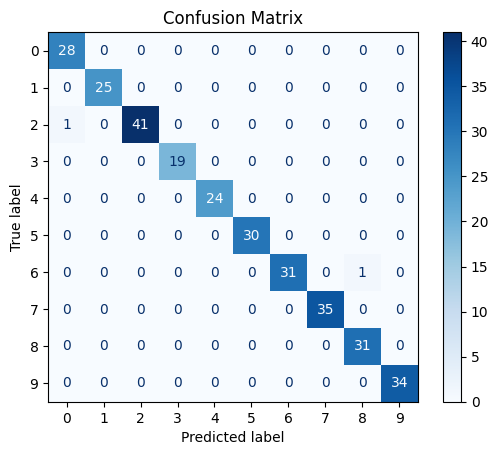

Test Accuracy: 99.33%


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


# Evaluation on Test Set
model.eval()
all_labels = []
all_predictions = []

with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        features = features.squeeze(1).permute(0, 2, 1)

        outputs = model(features)
        _, predicted = torch.max(outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(num_classes))

# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm_display.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Print Test Accuracy
test_accuracy = 100 * sum(np.array(all_labels) == np.array(all_predictions)) / len(all_labels)
print(f"Test Accuracy: {test_accuracy:.2f}%")

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Epoch [1/10], Loss: 2.3210, Train Accuracy: 14.38%
Validation Loss: 2.1129, Validation Accuracy: 25.67%
Epoch [2/10], Loss: 1.9611, Train Accuracy: 36.33%
Validation Loss: 1.7962, Validation Accuracy: 55.67%
Epoch [3/10], Loss: 1.6925, Train Accuracy: 56.21%
Validation Loss: 1.5205, Validation Accuracy: 61.67%
Epoch [4/10], Loss: 1.4441, Train Accuracy: 69.58%
Validation Loss: 1.3257, Validation Accuracy: 76.67%
Epoch [5/10], Loss: 1.2252, Train Accuracy: 79.88%
Validation Loss: 1.0937, Validation Accuracy: 81.33%
Epoch [6/10], Loss: 1.0063, Train Accuracy: 85.38%
Validation Loss: 0.8373, Validation Accuracy: 91.00%
Epoch [7/10], Loss: 0.7813, Train Accuracy: 93.29%
Validation Loss: 0.7360, Validation Accuracy: 87.00%
Epoch [8/10], Loss: 0.6475, Train Accuracy: 93.58%
Validation Loss: 0.5553, Validation Accuracy: 93.00%
Epoch [9/10], Loss: 0.5043, Train Accuracy: 96.38%
Validation Loss: 0.4131, Validation Accuracy: 96.33%
Epoch [10/10], Loss: 0.4096, Train Accuracy: 96.46%
Validation L

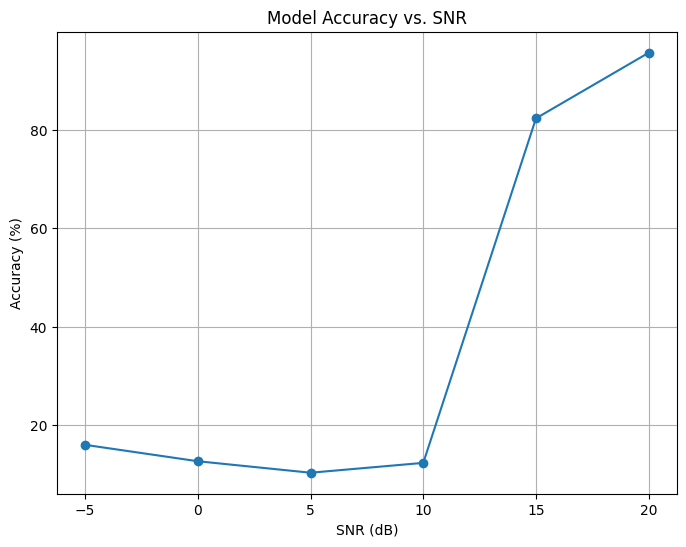

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchaudio
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Custom Dataset for Audio Data
class AudioDataset(Dataset):
    def __init__(self, folder_path, transform=None, max_len=16000):
        self.file_paths = []
        self.labels = []
        self.transform = transform
        self.max_len = max_len

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if os.path.isfile(file_path) and file_name[0].isdigit():
                self.file_paths.append(file_path)
                self.labels.append(int(file_name[0]))  # Extract label from the first character of the file name

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        waveform, sample_rate = torchaudio.load(file_path)

        # Padding or Trimming the waveform
        if waveform.size(1) > self.max_len:
            waveform = waveform[:, :self.max_len]  # Truncate
        else:
            waveform = F.pad(waveform, (0, self.max_len - waveform.size(1)))  # Pad with zeros

        if self.transform:
            features = self.transform(waveform)
        else:
            features = waveform

        return features, label

# Feature Extraction (e.g., MFCC)
def extract_mfcc(sample_rate, n_mfcc=40):
    return torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=n_mfcc,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

# Transformer-based Model
class TransformerDigitRecognizer(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes, dim_model=128, num_heads=4, num_layers=2):
        super(TransformerDigitRecognizer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        pos_encoding = self.compute_positional_encoding(seq_len, self.embedding.out_features).unsqueeze(0).to(x.device)
        x = self.embedding(x) + pos_encoding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.fc(x)
        return x

    @staticmethod
    def compute_positional_encoding(seq_len, dim_model):
        pe = torch.zeros(seq_len, dim_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / dim_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

# Add White Noise
def add_white_noise(waveform, snr):
    signal_power = waveform.pow(2).mean()
    noise_power = signal_power / (10 ** (snr / 10))
    noise = torch.randn_like(waveform) * torch.sqrt(noise_power)
    return waveform + noise

# Evaluate Model on Noisy Test Data
def evaluate_with_noise_on_test(model, test_loader, snr_values, device):
    accuracies = []
    for snr in snr_values:
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in test_loader:
                features, labels = features.to(device), labels.to(device)
                features = features.squeeze(1).permute(0, 2, 1)

                # Add noise only to test features
                noisy_features = torch.stack([add_white_noise(f, snr) for f in features])

                outputs = model(noisy_features)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"SNR: {snr} dB, Accuracy: {accuracy:.2f}%")
    return accuracies

# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 10

# Path to folder containing audio files
folder_path = "/content/gdrive/MyDrive/digit_voice/recordings"  # Replace with the actual folder path

# Transform for MFCC feature extraction
sample_rate = 16000
mfcc_transform = extract_mfcc(sample_rate)

# Data Preparation
dataset = AudioDataset(folder_path, transform=mfcc_transform)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model Initialization
input_dim = 40  # Number of MFCC features
seq_len = 100  # Adjust based on audio length
num_classes = 10
model = TransformerDigitRecognizer(input_dim, seq_len, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        features = features.squeeze(1).permute(0, 2, 1)  # Reshape to (batch_size, seq_len, input_dim)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            features = features.squeeze(1).permute(0, 2, 1)

            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

# Evaluation on Noisy Test Set
snr_values = [20, 15, 10, 5, 0, -5]  # SNR values in dB
noisy_accuracies = evaluate_with_noise_on_test(model, test_loader, snr_values, device)

# Plot Accuracy vs. SNR
plt.figure(figsize=(8, 6))
plt.plot(snr_values, noisy_accuracies, marker='o')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy vs. SNR')
plt.grid()
plt.show()



Epoch [1/50], Loss: 2.4016, Train Accuracy: 10.92%
Validation Loss: 2.2179, Validation Accuracy: 23.33%
Epoch [2/50], Loss: 2.1275, Train Accuracy: 26.12%
Validation Loss: 1.9945, Validation Accuracy: 29.33%
Epoch [3/50], Loss: 1.9984, Train Accuracy: 34.08%
Validation Loss: 1.8153, Validation Accuracy: 49.33%
Epoch [4/50], Loss: 1.8679, Train Accuracy: 41.96%
Validation Loss: 1.7642, Validation Accuracy: 36.67%
Epoch [5/50], Loss: 1.7750, Train Accuracy: 45.58%
Validation Loss: 1.6220, Validation Accuracy: 44.33%
Epoch [6/50], Loss: 1.6525, Train Accuracy: 50.71%
Validation Loss: 1.4722, Validation Accuracy: 50.67%
Epoch [7/50], Loss: 1.5366, Train Accuracy: 56.12%
Validation Loss: 1.2632, Validation Accuracy: 60.33%
Epoch [8/50], Loss: 1.4049, Train Accuracy: 63.58%
Validation Loss: 1.1129, Validation Accuracy: 66.67%
Epoch [9/50], Loss: 1.3160, Train Accuracy: 65.96%
Validation Loss: 1.0452, Validation Accuracy: 74.00%
Epoch [10/50], Loss: 1.2129, Train Accuracy: 69.33%
Validation L

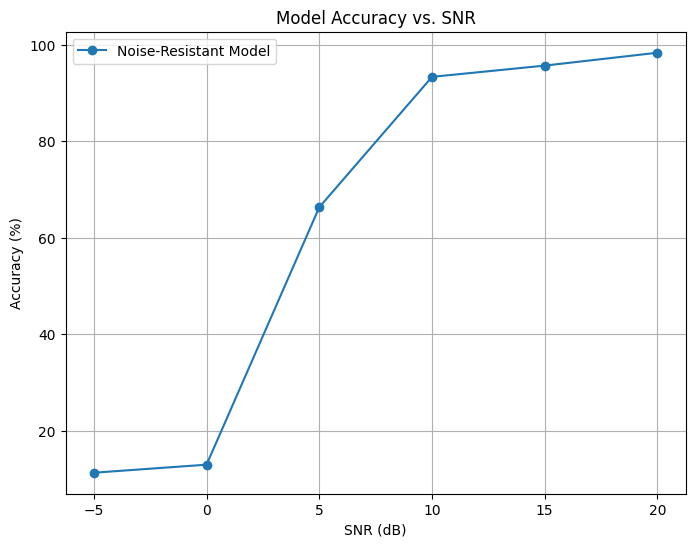

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchaudio
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Custom Dataset for Audio Data
class AudioDataset(Dataset):
    def __init__(self, folder_path, transform=None, max_len=16000):
        self.file_paths = []
        self.labels = []
        self.transform = transform
        self.max_len = max_len

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if os.path.isfile(file_path) and file_name[0].isdigit():
                self.file_paths.append(file_path)
                self.labels.append(int(file_name[0]))  # Extract label from the first character of the file name

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        waveform, sample_rate = torchaudio.load(file_path)

        # Padding or Trimming the waveform
        if waveform.size(1) > self.max_len:
            waveform = waveform[:, :self.max_len]  # Truncate
        else:
            waveform = F.pad(waveform, (0, self.max_len - waveform.size(1)))  # Pad with zeros

        if self.transform:
            features = self.transform(waveform)
        else:
            features = waveform

        return features, label

# Feature Extraction (e.g., MFCC)
def extract_mfcc(sample_rate, n_mfcc=40):
    return torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=n_mfcc,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

# Transformer-based Model
class TransformerDigitRecognizer(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes, dim_model=128, num_heads=4, num_layers=2):
        super(TransformerDigitRecognizer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=num_heads)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        pos_encoding = self.compute_positional_encoding(seq_len, self.embedding.out_features).unsqueeze(0).to(x.device)
        x = self.embedding(x) + pos_encoding
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.fc(x)
        return x

    @staticmethod
    def compute_positional_encoding(seq_len, dim_model):
        pe = torch.zeros(seq_len, dim_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / dim_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

# Add White Noise
def add_white_noise(waveform, snr):
    signal_power = waveform.pow(2).mean()
    noise_power = signal_power / (10 ** (snr / 10))
    noise = torch.randn_like(waveform) * torch.sqrt(noise_power)
    return waveform + noise

# Noisy Audio Dataset for Training Data Augmentation
class NoisyAudioDataset(Dataset):
    def __init__(self, dataset, snr_range=(20, 0)):
        self.dataset = dataset
        self.snr_range = snr_range  # SNR range for adding noise

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        features, label = self.dataset[idx]
        snr = np.random.uniform(*self.snr_range)  # Random SNR value
        noisy_features = add_white_noise(features, snr)
        return noisy_features, label

# Evaluate Model on Noisy Test Data
def evaluate_with_noise_on_test(model, test_loader, snr_values, device):
    accuracies = []
    for snr in snr_values:
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in test_loader:
                features, labels = features.to(device), labels.to(device)
                features = features.squeeze(1).permute(0, 2, 1)

                # Add noise only to test features
                noisy_features = torch.stack([add_white_noise(f, snr) for f in features])

                outputs = model(noisy_features)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"SNR: {snr} dB, Accuracy: {accuracy:.2f}%")
    return accuracies

# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 50

# Path to folder containing audio files
folder_path = "/content/gdrive/MyDrive/digit_voice/recordings"  # Replace with the actual folder path

# Transform for MFCC feature extraction
sample_rate = 16000
mfcc_transform = extract_mfcc(sample_rate)

# Data Preparation
dataset = AudioDataset(folder_path, transform=mfcc_transform)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Wrap training dataset with noise
snr_range = (20, 5)  # SNR range for augmentation
noisy_train_dataset = NoisyAudioDataset(train_dataset, snr_range)
noisy_train_loader = DataLoader(noisy_train_dataset, batch_size=batch_size, shuffle=True)

# Model Initialization
input_dim = 40  # Number of MFCC features
seq_len = 100  # Adjust based on audio length
num_classes = 10
model = TransformerDigitRecognizer(input_dim, seq_len, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for features, labels in noisy_train_loader:  # Use noisy training loader
        features, labels = features.to(device), labels.to(device)
        features = features.squeeze(1).permute(0, 2, 1)  # Reshape to (batch_size, seq_len, input_dim)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(noisy_train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            features = features.squeeze(1).permute(0, 2, 1)

            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

# Evaluation on Noisy Test Set
snr_values = [20, 15, 10, 5, 0, -5]  # SNR values in dB
noisy_accuracies = evaluate_with_noise_on_test(model, test_loader, snr_values, device)

# Plot Accuracy vs. SNR
plt.figure(figsize=(8, 6))
plt.plot(snr_values, noisy_accuracies, marker='o', label='Noise-Resistant Model')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy vs. SNR')
plt.legend()
plt.grid()
plt.show()


Epoch [1/50], Loss: 0.2370, Train Accuracy: 12.38%
Validation Loss: 0.2162, Validation Accuracy: 22.33%
Epoch [2/50], Loss: 0.2061, Train Accuracy: 33.12%
Validation Loss: 0.1981, Validation Accuracy: 41.33%
Epoch [3/50], Loss: 0.1878, Train Accuracy: 48.88%
Validation Loss: 0.1755, Validation Accuracy: 57.00%
Epoch [4/50], Loss: 0.1714, Train Accuracy: 61.62%
Validation Loss: 0.1587, Validation Accuracy: 66.33%
Epoch [5/50], Loss: 0.1521, Train Accuracy: 75.29%
Validation Loss: 0.1390, Validation Accuracy: 80.33%
Epoch [6/50], Loss: 0.1359, Train Accuracy: 80.08%
Validation Loss: 0.1253, Validation Accuracy: 88.00%
Epoch [7/50], Loss: 0.1186, Train Accuracy: 88.00%
Validation Loss: 0.1070, Validation Accuracy: 91.67%
Epoch [8/50], Loss: 0.1051, Train Accuracy: 91.46%
Validation Loss: 0.1019, Validation Accuracy: 87.33%
Epoch [9/50], Loss: 0.0941, Train Accuracy: 93.17%
Validation Loss: 0.0863, Validation Accuracy: 95.33%
Epoch [10/50], Loss: 0.0853, Train Accuracy: 96.04%
Validation L

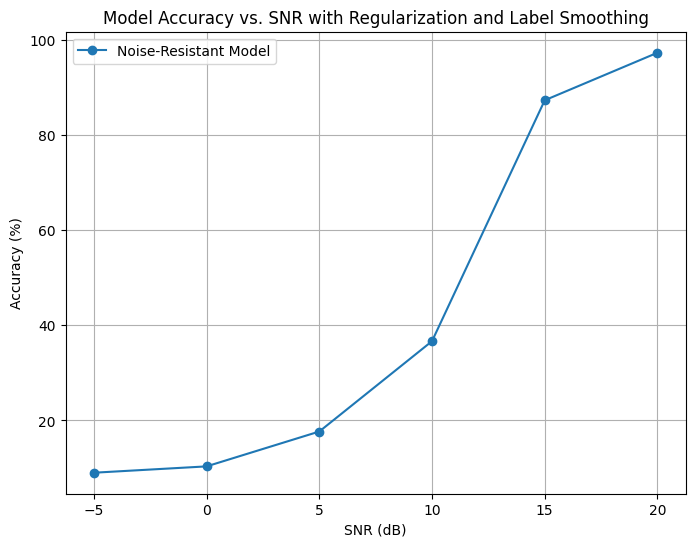

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchaudio
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Custom Dataset for Audio Data
class AudioDataset(Dataset):
    def __init__(self, folder_path, transform=None, max_len=16000):
        self.file_paths = []
        self.labels = []
        self.transform = transform
        self.max_len = max_len

        for file_name in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file_name)
            if os.path.isfile(file_path) and file_name[0].isdigit():
                self.file_paths.append(file_path)
                self.labels.append(int(file_name[0]))  # Extract label from the first character of the file name

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]

        waveform, sample_rate = torchaudio.load(file_path)

        # Padding or Trimming the waveform
        if waveform.size(1) > self.max_len:
            waveform = waveform[:, :self.max_len]  # Truncate
        else:
            waveform = F.pad(waveform, (0, self.max_len - waveform.size(1)))  # Pad with zeros

        if self.transform:
            features = self.transform(waveform)
        else:
            features = waveform

        return features, label

# Feature Extraction (e.g., MFCC)
def extract_mfcc(sample_rate, n_mfcc=40):
    return torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=n_mfcc,
        melkwargs={"n_fft": 400, "hop_length": 160, "n_mels": 40}
    )

# Transformer-based Model with Dropout
class TransformerDigitRecognizer(nn.Module):
    def __init__(self, input_dim, seq_len, num_classes, dim_model=128, num_heads=4, num_layers=2, dropout=0.1):
        super(TransformerDigitRecognizer, self).__init__()
        self.embedding = nn.Linear(input_dim, dim_model)
        self.dropout = nn.Dropout(dropout)  # Add dropout
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=dim_model, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(dim_model, num_classes)

    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        pos_encoding = self.compute_positional_encoding(seq_len, self.embedding.out_features).unsqueeze(0).to(x.device)
        x = self.embedding(x) + pos_encoding
        x = self.dropout(x)  # Apply dropout
        x = self.transformer_encoder(x)
        x = x.mean(dim=1)  # Global average pooling
        x = self.fc(x)
        return x

    @staticmethod
    def compute_positional_encoding(seq_len, dim_model):
        pe = torch.zeros(seq_len, dim_model)
        position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, dim_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / dim_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

# Label Smoothing CrossEntropy Loss
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        log_probs = torch.nn.functional.log_softmax(pred, dim=-1)
        targets = torch.zeros_like(log_probs).scatter_(1, target.unsqueeze(1), 1)
        targets = (1 - self.smoothing) * targets + self.smoothing / log_probs.size(1)
        loss = (-targets * log_probs).mean()
        return loss

# Add White Noise
def add_white_noise(waveform, snr):
    signal_power = waveform.pow(2).mean()
    noise_power = signal_power / (10 ** (snr / 10))
    noise = torch.randn_like(waveform) * torch.sqrt(noise_power)
    return waveform + noise

# Evaluate Model on Noisy Test Data
def evaluate_with_noise_on_test(model, test_loader, snr_values, device):
    accuracies = []
    for snr in snr_values:
        correct = 0
        total = 0
        with torch.no_grad():
            for features, labels in test_loader:
                features, labels = features.to(device), labels.to(device)
                features = features.squeeze(1).permute(0, 2, 1)

                # Add noise only to test features
                noisy_features = torch.stack([add_white_noise(f, snr) for f in features])

                outputs = model(noisy_features)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"SNR: {snr} dB, Accuracy: {accuracy:.2f}%")
    return accuracies

# Hyperparameters
batch_size = 64
learning_rate = 0.001
epochs = 50

# Path to folder containing audio files
folder_path = "/content/gdrive/MyDrive/digit_voice/recordings"  # Replace with the actual folder path

# Transform for MFCC feature extraction
sample_rate = 16000
mfcc_transform = extract_mfcc(sample_rate)

# Data Preparation
dataset = AudioDataset(folder_path, transform=mfcc_transform)
train_size = int(0.8 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Model Initialization
input_dim = 40  # Number of MFCC features
seq_len = 100  # Adjust based on audio length
num_classes = 10
model = TransformerDigitRecognizer(input_dim, seq_len, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss and Optimizer
criterion = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training Loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for features, labels in train_loader:  # Use original training loader
        features, labels = features.to(device), labels.to(device)
        features = features.squeeze(1).permute(0, 2, 1)  # Reshape to (batch_size, seq_len, input_dim)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = 100 * correct_train / total_train
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Train Accuracy: {train_accuracy:.2f}%")

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            features = features.squeeze(1).permute(0, 2, 1)

            outputs = model(features)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_accuracy = 100 * correct / total
    print(f"Validation Loss: {val_loss/len(val_loader):.4f}, Validation Accuracy: {val_accuracy:.2f}%")

# Evaluation on Noisy Test Set
snr_values = [20, 15, 10, 5, 0, -5]  # SNR values in dB
noisy_accuracies = evaluate_with_noise_on_test(model, test_loader, snr_values, device)

# Plot Accuracy vs. SNR
plt.figure(figsize=(8, 6))
plt.plot(snr_values, noisy_accuracies, marker='o', label='Noise-Resistant Model')
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy vs. SNR with Regularization and Label Smoothing')
plt.legend()
plt.grid()
plt.show()
